In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sklearn

from keras.models import Sequential
from keras.layers import Dense, Activation
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder

In [3]:
COLUMN_DEW_2M = "dewpoint_2m (°C)"

df = pd.read_csv("herford_weather.csv", parse_dates=['time']).set_index('time')
display(df.index.dtype)
df[:5]

dtype('<M8[ns]')

,temperature_2m (°C),relativehumidity_2m (%),dewpoint_2m (°C),apparent_temperature (°C),pressure_msl (hPa),surface_pressure (hPa),precipitation (mm),rain (mm),snowfall (cm),weathercode (wmo code),...,et0_fao_evapotranspiration (mm),vapor_pressure_deficit (kPa),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
time,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00,-2.3,80,-5.3,-7.2,1003.4,988.2,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 01:00:00,-2.1,80,-5.2,-7.0,1003.8,988.6,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 02:00:00,-2.0,79,-5.2,-6.9,1003.9,988.7,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 03:00:00,-2.1,79,-5.3,-7.0,1004.0,988.8,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 04:00:00,-2.2,78,-5.5,-7.1,1004.5,989.3,0.0,0.0,0.0,3,...,0.01,0.12,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34


In [56]:
corr = df.corr()
corr[COLUMN_DEW_2M].sort_values()[-7:]

soil_temperature_100_to_255cm (°C)    0.502192
soil_temperature_28_to_100cm (°C)     0.792630
soil_temperature_7_to_28cm (°C)       0.870824
soil_temperature_0_to_7cm (°C)        0.876163
temperature_2m (°C)                   0.895681
apparent_temperature (°C)             0.917602
dewpoint_2m (°C)                      1.000000
Name: dewpoint_2m (°C), dtype: float64

In [17]:
X = df[['weathercode (wmo code)']]

ohe = OneHotEncoder()
ohe.fit(X)

print('categories: {}'.format(ohe.categories_))
X_ohe = ohe.transform(X)
print('array: {}'.format(X_ohe[:5]))

df[:5]

categories: [array([ 0,  1,  2,  3, 51, 53, 55, 61, 63, 65, 71, 73, 75])]
array: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 5 stored elements and shape (5, 13)>
  Coords	Values
  (0, 3)	1.0
  (1, 3)	1.0
  (2, 3)	1.0
  (3, 3)	1.0
  (4, 3)	1.0


,temperature_2m (°C),relativehumidity_2m (%),dewpoint_2m (°C),apparent_temperature (°C),pressure_msl (hPa),surface_pressure (hPa),precipitation (mm),rain (mm),snowfall (cm),weathercode (wmo code),...,et0_fao_evapotranspiration (mm),vapor_pressure_deficit (kPa),soil_temperature_0_to_7cm (°C),soil_temperature_7_to_28cm (°C),soil_temperature_28_to_100cm (°C),soil_temperature_100_to_255cm (°C),soil_moisture_0_to_7cm (m³/m³),soil_moisture_7_to_28cm (m³/m³),soil_moisture_28_to_100cm (m³/m³),soil_moisture_100_to_255cm (m³/m³)
time,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00,-2.3,80,-5.3,-7.2,1003.4,988.2,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 01:00:00,-2.1,80,-5.2,-7.0,1003.8,988.6,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 02:00:00,-2.0,79,-5.2,-6.9,1003.9,988.7,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 03:00:00,-2.1,79,-5.3,-7.0,1004.0,988.8,0.0,0.0,0.0,3,...,0.01,0.11,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34
1996-01-01 04:00:00,-2.2,78,-5.5,-7.1,1004.5,989.3,0.0,0.0,0.0,3,...,0.01,0.12,-1.7,-0.5,2.3,7.8,0.36,0.364,0.346,0.34


C:\Users\DECOMEI\AppData\Local\Temp\ipykernel_59596\1319634458.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x='month', y=COLUMN_DEW_2M, color='b', ax=axs[0], ci=False)
C:\Users\DECOMEI\AppData\Local\Temp\ipykernel_59596\1319634458.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x='weekday', y=COLUMN_DEW_2M, color='r', ax=axs[1], ci=False)
C:\Users\DECOMEI\AppData\Local\Temp\ipykernel_59596\1319634458.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.barplot(data=df, x='hour', y=COLUMN_DEW_2M, color='g', ax=axs[2], ci=False)


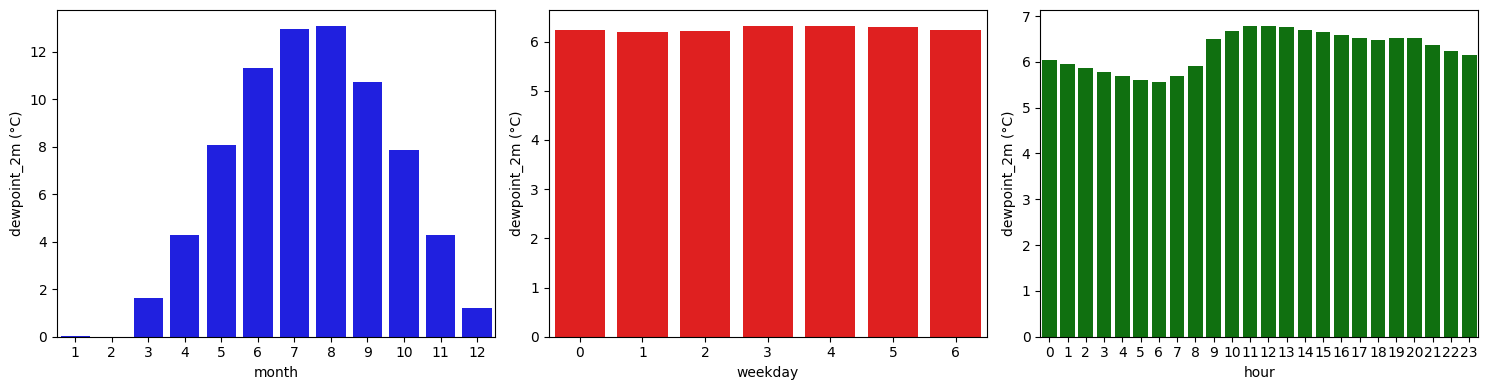

In [27]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(15,4))

df['weekday'] = df.index.weekday
df['month'] = df.index.month
df['hour'] = df.index.hour
df[['weekday', 'month', 'hour']].head()

sns.barplot(data=df, x='month', y=COLUMN_DEW_2M, color='b', ax=axs[0], ci=False)
sns.barplot(data=df, x='weekday', y=COLUMN_DEW_2M, color='r', ax=axs[1], ci=False)
sns.barplot(data=df, x='hour', y=COLUMN_DEW_2M, color='g', ax=axs[2], ci=False)
plt.tight_layout()

## Hauptkomponentenanalyse

In [39]:
from sklearn.model_selection import train_test_split

x_train_og = df.copy().drop([COLUMN_DEW_2M], axis=1)
y_train_og = df[[COLUMN_DEW_2M]]

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [40]:
from sklearn.decomposition import PCA 
pca = PCA(n_components=0.9) 

X_train_fact = pca.fit_transform(x_train_og)
# X_test_fact = pca.transform(X_test) 
exp_var = pca.explained_variance_ratio_ 

sum_exp_var = sum(exp_var)
print('explained variance by factor:', exp_var) 
print('sum explained variance all factors:{:.3f}'.format(sum_exp_var))


explained variance by factor: [0.75775737 0.11869953 0.05424197]
sum explained variance all factors:0.931


In [ ]:
X_train_final, X_val, y_train, y_val = train_test_split(X_train_fact, y_train_og, test_size=0.2, random_state=42)

## Model training

In [58]:
train_attrib = [
    "temperature_2m (°C)",
    'apparent_temperature (°C)',
    "soil_temperature_0_to_7cm (°C)",
    'weathercode (wmo code)',
    "month"
]


X = df[train_attrib].values # Trainingsdaten
y = df[[COLUMN_DEW_2M]].values #Targetvektor Arztkosten

scaler_X = StandardScaler() # Merkmalsskalierung mit Standardscaler
X = scaler_X.fit_transform(X)
scaler_y = StandardScaler() # Targetvektor wird auch skaliert
y = scaler_y.fit_transform(y)

x_train_1, X_val_1, y_train_1, y_val_1 = train_test_split(X, y, test_size=0.2, random_state=42)


X.shape, y.shape

((239570, 5), (239570, 1))

Epoch 1/5


c:\Users\DECOMEI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2995/2995 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.0000e+00 - loss: 0.1723
Epoch 2/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.0000e+00 - loss: 0.1301
Epoch 3/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.1239
Epoch 4/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.1218
Epoch 5/5
2995/2995 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.0000e+00 - loss: 0.1211
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 5s 841us/step
r2 = 0.879


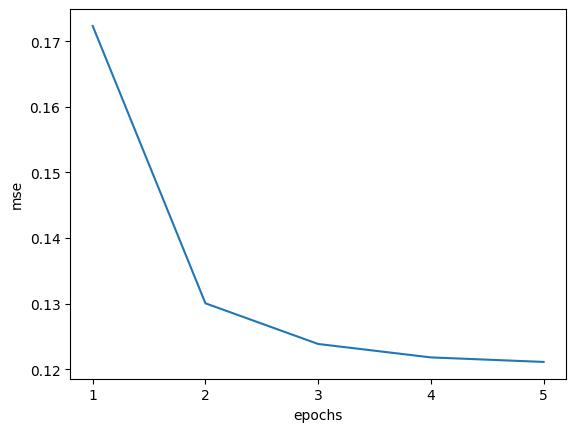

In [59]:
model = Sequential() # leeres Modellobjekt instanziieren
model.add(Dense(units=1, input_shape=(5,)))

model.compile(loss='mse', optimizer='sgd', metrics=['accuracy'])

history = model.fit(x_train_1, y_train_1, epochs=5, batch_size=64)

# Check model accuracy
y_pred = model.predict(x_train_1) # alle Targets mit trainiertem Modell rechnen
r2 = r2_score(y_train_1, y_pred) # R2 rechnen für Predictions und reale Targetvektoren
print('r2 = {:.3f}'.format(r2))


loss_mse = history.history['loss']
plt.xticks(range(1, len(loss_mse)+1))
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)

In [ ]:
# With pca values

model = Sequential() # leeres Modellobjekt instanziieren
model.add(Dense(units=1, input_shape=(3,)))

model.compile(loss='mse', optimizer='sgd', metrics=['accuracy'])

history = model.fit(X_train_final, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=32)

# Check model accuracy
y_pred = model.predict(X_train_final) # alle Targets mit trainiertem Modell rechnen
r2 = r2_score(y_train, y_pred) # R2 rechnen für Predictions und reale Targetvektoren
print('r2 = {:.3f}'.format(r2))


loss_mse = history.history['loss']
plt.xticks(range(1, len(loss_mse)+1))
plt.ylabel('mse')
plt.xlabel('epochs')
plt.plot(range(1, len(loss_mse)+1), loss_mse)

Epoch 1/5


c:\Users\DECOMEI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5990/5990 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0039 - val_loss: nan
Epoch 2/5
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0039 - val_loss: nan
Epoch 3/5
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0039 - val_loss: nan
Epoch 4/5
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0039 - val_loss: nan
Epoch 5/5
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.0038 - loss: nan - val_accuracy: 0.0039 - val_loss: nan
5990/5990 ━━━━━━━━━━━━━━━━━━━━ 6s 963us/step


ValueError: Input contains NaN.